# 16 — Pretraining a Tiny GPT End to End

## Goal

The previous lessons built the components of a decoder-only language model
individually.

This lesson connects those components into a complete pretraining
experiment:

<pre>
raw text
    ↓
tokenization
    ↓
train / validation split
    ↓
sequence batches
    ↓
GPT
    ↓
next-token cross-entropy
    ↓
backpropagation
    ↓
AdamW
    ↓
learning-rate schedule
    ↓
validation
    ↓
checkpoint
    ↓
autoregressive generation
</pre>

The goal is not to train a competitive language model.

The goal is to understand and observe the complete lifecycle of language
model pretraining.

In [1]:
import math
import time
from pathlib import Path

import torch
import torch.nn.functional as F

from llmfp import GPT, GPTConfig
from llmfp.data import (
    CharacterTokenizer,
    get_batch,
    split_token_stream,
    tokens_per_step,
)
from llmfp.generation import (
    generate_greedy_cached,
    generate_sampled_cached,
)
from llmfp.training import (
    warmup_cosine_learning_rate,
)
from llmfp.utils import (
    count_parameters,
    perplexity_from_loss,
    print_parameter_breakdown,
)

import matplotlib.pyplot as plt


In [2]:
device: torch.device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("device:", device)

if device.type == "cuda":
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

device: cuda
GPU: NVIDIA RTX 3000 Ada Generation Laptop GPU


In [3]:
data_path: Path = Path("../data/raw/tinyshakespeare.txt")

if not data_path.exists():
    raise FileNotFoundError(
        "Expected Tiny Shakespeare at ../data/raw/tinyshakespeare.txt"
    )

text: str = data_path.read_text(encoding="utf-8")

print(
    "number of characters:",
    len(text),
)

print()
print(text[:500])

number of characters: 1115390

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


## 1. Building the Training Corpus

A language model does not directly consume text.

It consumes integer token IDs.

For this first end-to-end pretraining experiment, we use a character-level
tokenizer so that the training pipeline remains fully visible.

If the corpus contains a vocabulary

$$
\mathcal{V}
=
\{c_0,c_1,\ldots,c_{V-1}\},
$$

each character is assigned one integer ID:

$$
c_i
\leftrightarrow
i.
$$

The model itself does not know that these IDs correspond to characters.

It only receives sequences of integers.

In [4]:
characters: list[str] = sorted(set(text))

vocab_size: int = len(characters)

character_to_id: dict[str, int] = {
    character: index for index, character in enumerate(characters)
}

id_to_character: dict[int, str] = {
    index: character for character, index in character_to_id.items()
}

print("vocab size:", vocab_size)
print("vocabulary: \n", "".join(characters))

vocab size: 65
vocabulary: 
 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


In [5]:
def encode(
    text: str,
) -> list[int]:
    """Convert characters into integer token IDs.

    Args:
        text: Character string to encode.

    Returns:
        Integer token IDs.
    """
    return [character_to_id[character] for character in text]


def decode(
    token_ids: list[int],
) -> str:
    """Convert integer token IDs back into characters.

    Args:
        token_ids: Character-level token IDs.

    Returns:
        Decoded text.
    """
    return "".join(id_to_character[token_id] for token_id in token_ids)

In [6]:
example_text: str = "Hello"

example_ids: list[int] = encode(example_text)

print("text:", example_text)
print("ids:", example_ids)
print("decoded:", decode(example_ids))

text: Hello
ids: [20, 43, 50, 50, 53]
decoded: Hello


In [7]:
token_ids: torch.Tensor = torch.tensor(
    encode(text),
    dtype=torch.long,
)

print("shape:", token_ids.shape)
print("dtype:", token_ids.dtype)
print("first tokens:", token_ids[:20])

shape: torch.Size([1115390])
dtype: torch.int64
first tokens: tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56])


In [8]:
split_index: int = int(0.9 * len(token_ids))

train_tokens: torch.Tensor = token_ids[:split_index]

validation_tokens: torch.Tensor = token_ids[split_index:]

print(
    "train tokens:",
    len(train_tokens),
)

print(
    "validation tokens:",
    len(validation_tokens),
)

train tokens: 1003851
validation tokens: 111539


## 2. From a Token Stream to Training Batches

After tokenization, the corpus is one long sequence:

$$
x_0,x_1,x_2,\ldots,x_N.
$$

A decoder-only language model learns the next-token prediction problem:

$$
p(x_{t+1}\mid x_{\le t}).
$$

For a context length $T$, each training example therefore needs

$$
T+1
$$

consecutive tokens.

The first $T$ tokens become the model input, while the final $T$ tokens,
shifted by one position, become the targets.

In [9]:
context_length: int = 8

start_index: int = 100

window: torch.Tensor = train_tokens[
    start_index : start_index + context_length + 1
]

inputs: torch.Tensor = window[:-1]
targets: torch.Tensor = window[1:]

print("window shape:", window.shape)
print("input shape:", inputs.shape)
print("target shape:", targets.shape)

print()
print("window:")
print(decode(window.tolist()))

print()
print("input:")
print(decode(inputs.tolist()))

print()
print("target:")
print(decode(targets.tolist()))

window shape: torch.Size([9])
input shape: torch.Size([8])
target shape: torch.Size([8])

window:
 are all 

input:
 are all

target:
are all 


In [10]:
for position in range(context_length):
    context: str = decode(inputs[: position + 1].tolist())

    target_character: str = decode([targets[position].item()])

    print(
        repr(context),
        "->",
        repr(target_character),
    )

' ' -> 'a'
' a' -> 'r'
' ar' -> 'e'
' are' -> ' '
' are ' -> 'a'
' are a' -> 'l'
' are al' -> 'l'
' are all' -> ' '


In [11]:
def get_batch(
    tokens: torch.Tensor,
    batch_size: int,
    context_length: int,
    device: torch.device,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Sample random next-token training sequences.

    Args:
        tokens: One-dimensional token stream.
        batch_size: Number of independent sequences in the batch.
        context_length: Number of input positions per sequence.
        device: Device where the returned batch should live.

    Returns:
        A tuple `(inputs, targets)`, both with shape
        `(B, T)`.
    """
    if tokens.ndim != 1:
        raise ValueError("tokens must be a one-dimensional token stream.")

    if len(tokens) <= context_length:
        raise ValueError("token stream must be longer than context_length.")

    maximum_start: int = len(tokens) - context_length - 1

    start_indices: torch.Tensor = torch.randint(
        low=0,
        high=maximum_start + 1,
        size=(batch_size,),
    )

    inputs: torch.Tensor = torch.stack(
        [tokens[start : start + context_length] for start in start_indices]
    )

    targets: torch.Tensor = torch.stack(
        [
            tokens[start + 1 : start + context_length + 1]
            for start in start_indices
        ]
    )

    return (
        inputs.to(device),
        targets.to(device),
    )

In [12]:
batch_size: int = 4
context_length: int = 16

batch_inputs, batch_targets = get_batch(
    train_tokens,
    batch_size=batch_size,
    context_length=context_length,
    device=device,
)

print(
    "inputs:",
    batch_inputs.shape,
)

print(
    "targets:",
    batch_targets.shape,
)

print()
print("first input:")
print(decode(batch_inputs[0].cpu().tolist()))

print()
print("first target:")
print(decode(batch_targets[0].cpu().tolist()))

inputs: torch.Size([4, 16])
targets: torch.Size([4, 16])

first input:
ancient quarrels

first target:
ncient quarrels,


In [13]:
def tokens_per_step(
    batch_size: int,
    context_length: int,
) -> int:
    """Return the number of prediction targets in one batch."""
    return batch_size * context_length


print(
    tokens_per_step(
        batch_size=32,
        context_length=256,
    )
)

8192


## 3. Building the First Pretraining Model

The first model should be large enough to learn meaningful structure but
small enough to iterate quickly.

We use:

$$
C=256,
\qquad
L=4,
\qquad
H_Q=8,
\qquad
H_{KV}=2.
$$

Therefore the head dimension is

$$
D
=
\frac{C}{H_Q}
=
32.
$$

This is a GQA model: every KV head is shared by

$$
\frac{H_Q}{H_{KV}}
=
4
$$

query heads.

In [14]:
config = GPTConfig(
    vocab_size=vocab_size,
    embedding_dim=256,
    num_query_heads=8,
    num_kv_heads=2,
    num_layers=4,
    hidden_dim=768,
)

model = GPT(config).to(device)

In [15]:
parameter_count: int = count_parameters(model)

print(f"parameters: {parameter_count:,}")

parameters: 3,050,240


In [16]:
print_parameter_breakdown(model)

token_embedding          16640 (  0.5%)
blocks                 3016704 ( 98.9%)
final_norm                 256 (  0.0%)
lm_head                  16640 (  0.5%)
------------------------------------------
total                  3050240


In [17]:
batch_size: int = 32
context_length: int = 256

inputs, targets = get_batch(
    train_tokens,
    batch_size=batch_size,
    context_length=context_length,
    device=device,
)

model.eval()

with torch.no_grad():
    logits: torch.Tensor = model(inputs)

print(
    "inputs:",
    inputs.shape,
)

print(
    "targets:",
    targets.shape,
)

print(
    "logits:",
    logits.shape,
)

inputs: torch.Size([32, 256])
targets: torch.Size([32, 256])
logits: torch.Size([32, 256, 65])


In [18]:
uniform_baseline_loss: float = math.log(vocab_size)

print(
    "uniform baseline loss:",
    uniform_baseline_loss,
)

uniform baseline loss: 4.174387269895637


In [19]:
loss: torch.Tensor = F.cross_entropy(
    logits.reshape(
        -1,
        vocab_size,
    ),
    targets.reshape(-1),
)

print(
    "initial loss:",
    loss.item(),
)

initial loss: 4.375306129455566


In [20]:
tokenizer = CharacterTokenizer.from_text(text)

vocab_size: int = tokenizer.vocab_size

token_ids = torch.tensor(
    tokenizer.encode(text),
    dtype=torch.long,
)

In [21]:
tokenizer.decode(token_ids[:100].tolist())


'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou'

In [22]:
train_tokens, validation_tokens = split_token_stream(
    token_ids,
    train_fraction=0.9,
)

In [23]:
inputs, targets = get_batch(
    train_tokens,
    batch_size=32,
    context_length=256,
    device=device,
)

## 4. One Training Step Under the Microscope

A training loop is only a repetition of one parameter-update step.

Before writing the loop, we inspect one step explicitly:

<pre>
sample a batch
    ↓
forward pass
    ↓
next-token cross-entropy
    ↓
clear old gradients
    ↓
backpropagation
    ↓
inspect / clip gradients
    ↓
AdamW update
    ↓
new parameters
</pre>

The goal is to understand exactly what changes during one optimization
step before hiding the process inside a loop.

In [24]:
total_steps: int = 5000
warmup_steps: int = 200

peak_learning_rate: float = 3e-4
minimum_learning_rate: float = 3e-5

weight_decay: float = 0.1
max_grad_norm: float = 1.0

In [25]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=peak_learning_rate,
    betas=(0.9, 0.95),
    weight_decay=weight_decay,
)

In [26]:
learning_rate: float = warmup_cosine_learning_rate(
    step=1,
    total_steps=total_steps,
    warmup_steps=warmup_steps,
    peak_learning_rate=peak_learning_rate,
    minimum_learning_rate=minimum_learning_rate,
)

print(learning_rate)

1.4999999999999998e-06


In [27]:
for parameter_group in optimizer.param_groups:
    parameter_group["lr"] = learning_rate


In [28]:
inputs, targets = get_batch(
    train_tokens,
    batch_size=batch_size,
    context_length=context_length,
    device=device,
)

print("inputs:", inputs.shape)
print("targets:", targets.shape)

inputs: torch.Size([32, 256])
targets: torch.Size([32, 256])


In [29]:
emedding_before: torch.Tensor = model.token_embedding.weight.detach().clone()


In [30]:
gradient_norm: torch.Tensor = torch.nn.utils.clip_grad_norm_(
    model.parameters(),
    max_norm=max_grad_norm,
)

print(
    "gradient norm before clipping:",
    gradient_norm.item(),
)

gradient norm before clipping: 0.0


In [31]:
parameter = model.token_embedding.weight

optimizer_state = optimizer.state[parameter]

print(optimizer_state.keys())

dict_keys([])


## 4. End-to-End Pretraining

We now connect the complete pipeline:

<pre>
raw text
    ↓
character tokenizer
    ↓
train / validation streams
    ↓
random context windows
    ↓
GPT
    ↓
next-token cross-entropy
    ↓
AdamW
    ↓
warmup + cosine decay
    ↓
validation
    ↓
checkpoint
    ↓
generation
</pre>

The goal is to train the first complete language model built from the
components developed throughout the previous lessons.

In [32]:
batch_size: int = 32
context_length: int = 256

total_steps: int = 5000
evaluation_interval: int = 250
evaluation_batches: int = 20

peak_learning_rate: float = 3e-4
minimum_learning_rate: float = 3e-5
warmup_steps: int = 200

weight_decay: float = 0.1
max_grad_norm: float = 1.0

checkpoint_interval: int = 1000

In [33]:
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

config = GPTConfig(
    vocab_size=vocab_size,
    embedding_dim=256,
    num_query_heads=8,
    num_kv_heads=2,
    num_layers=4,
    hidden_dim=768,
)

model = GPT(config).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=peak_learning_rate,
    betas=(0.9, 0.95),
    weight_decay=weight_decay,
)

print(f"parameters: {count_parameters(model):,}")

parameters: 3,050,240


In [34]:
@torch.no_grad()
def estimate_loss(
    model: GPT,
    train_tokens: torch.Tensor,
    validation_tokens: torch.Tensor,
    *,
    batch_size: int,
    context_length: int,
    evaluation_batches: int,
    device: torch.device,
) -> dict[str, float]:
    """Estimate mean train and validation loss.

    Args:
        model: Language model being evaluated.
        train_tokens: Training token stream.
        validation_tokens: Validation token stream.
        batch_size: Evaluation batch size.
        context_length: Number of prediction positions per sequence.
        evaluation_batches: Number of random batches per split.
        device: Device used for evaluation.

    Returns:
        Mean loss for the train and validation splits.
    """
    was_training: bool = model.training
    model.eval()

    results: dict[str, float] = {}

    splits: dict[str, torch.Tensor] = {
        "train": train_tokens,
        "validation": validation_tokens,
    }

    for split_name, tokens in splits.items():
        total_loss: float = 0.0

        for _ in range(evaluation_batches):
            inputs, targets = get_batch(
                tokens,
                batch_size=batch_size,
                context_length=context_length,
                device=device,
            )

            logits: torch.Tensor = model(inputs)

            loss: torch.Tensor = F.cross_entropy(
                logits.reshape(
                    -1,
                    logits.shape[-1],
                ),
                targets.reshape(-1),
            )

            total_loss += loss.item()

        results[split_name] = total_loss / evaluation_batches

    if was_training:
        model.train()

    return results

In [35]:
checkpoint_dir: Path = Path("../checkpoints/tiny_shakespeare")

checkpoint_dir.mkdir(
    parents=True,
    exist_ok=True,
)

In [36]:
model.train()

start_time: float = time.perf_counter()

processed_tokens: int = 0
logged_steps: list[int] = []
train_losses: list[float] = []
validation_losses: list[float] = []

for step in range(1, total_steps + 1):
    learning_rate: float = warmup_cosine_learning_rate(
        step=step,
        total_steps=total_steps,
        warmup_steps=warmup_steps,
        peak_learning_rate=peak_learning_rate,
        minimum_learning_rate=minimum_learning_rate,
    )

    for parameter_group in optimizer.param_groups:
        parameter_group["lr"] = learning_rate

    inputs, targets = get_batch(
        train_tokens,
        batch_size=batch_size,
        context_length=context_length,
        device=device,
    )

    optimizer.zero_grad(set_to_none=True)

    logits: torch.Tensor = model(inputs)

    loss: torch.Tensor = F.cross_entropy(
        logits.reshape(
            -1,
            logits.shape[-1],
        ),
        targets.reshape(-1),
    )

    loss.backward()

    gradient_norm: torch.Tensor = torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=max_grad_norm,
    )

    optimizer.step()

    processed_tokens += tokens_per_step(
        batch_size=batch_size,
        context_length=context_length,
    )

    if step == 1 or step % evaluation_interval == 0 or step == total_steps:
        losses: dict[str, float] = estimate_loss(
            model,
            train_tokens,
            validation_tokens,
            batch_size=batch_size,
            context_length=context_length,
            evaluation_batches=evaluation_batches,
            device=device,
        )

        logged_steps.append(step)

        train_losses.append(losses["train"])

        validation_losses.append(losses["validation"])

        elapsed_seconds: float = time.perf_counter() - start_time

        tokens_per_second: float = processed_tokens / elapsed_seconds

        train_perplexity: float = perplexity_from_loss(losses["train"])

        validation_perplexity: float = perplexity_from_loss(
            losses["validation"]
        )

        print(
            f"step {step:5d}/{total_steps} | "
            f"lr {learning_rate:.2e} | "
            f"train {losses['train']:.4f} | "
            f"val {losses['validation']:.4f} | "
            f"train ppl {train_perplexity:.2f} | "
            f"val ppl {validation_perplexity:.2f} | "
            f"grad {gradient_norm.item():.3f} | "
            f"{tokens_per_second:,.0f} tok/s"
        )

    if step % checkpoint_interval == 0 or step == total_steps:
        checkpoint_path: Path = checkpoint_dir / f"step_{step:05d}.pt"

        torch.save(
            {
                "step": step,
                "model_config": config,
                "model_state_dict": (model.state_dict()),
                "optimizer_state_dict": (optimizer.state_dict()),
                "train_loss": loss.item(),
                "tokens_processed": (processed_tokens),
            },
            checkpoint_path,
        )

step     1/5000 | lr 1.50e-06 | train 4.3439 | val 4.3400 | train ppl 77.01 | val ppl 76.70 | grad 1.673 | 5,404 tok/s
step   250/5000 | lr 3.00e-04 | train 2.0393 | val 2.0810 | train ppl 7.69 | val ppl 8.01 | grad 0.547 | 96,640 tok/s
step   500/5000 | lr 2.97e-04 | train 1.6158 | val 1.7813 | train ppl 5.03 | val ppl 5.94 | grad 0.708 | 97,696 tok/s
step   750/5000 | lr 2.91e-04 | train 1.4696 | val 1.6637 | train ppl 4.35 | val ppl 5.28 | grad 0.770 | 97,726 tok/s
step  1000/5000 | lr 2.82e-04 | train 1.3898 | val 1.6071 | train ppl 4.01 | val ppl 4.99 | grad 0.690 | 97,946 tok/s
step  1250/5000 | lr 2.69e-04 | train 1.3343 | val 1.5702 | train ppl 3.80 | val ppl 4.81 | grad 0.693 | 98,291 tok/s
step  1500/5000 | lr 2.54e-04 | train 1.2920 | val 1.5402 | train ppl 3.64 | val ppl 4.67 | grad 0.701 | 98,933 tok/s
step  1750/5000 | lr 2.36e-04 | train 1.2471 | val 1.5413 | train ppl 3.48 | val ppl 4.67 | grad 0.722 | 99,377 tok/s
step  2000/5000 | lr 2.17e-04 | train 1.2328 | val 1.53

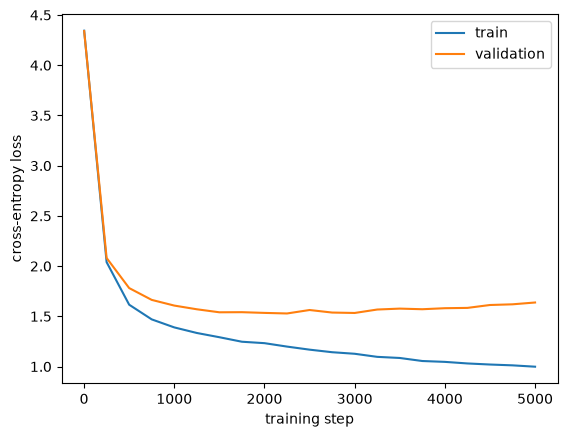

In [37]:
plt.figure()

plt.plot(
    logged_steps,
    train_losses,
    label="train",
)

plt.plot(
    logged_steps,
    validation_losses,
    label="validation",
)

plt.xlabel("training step")
plt.ylabel("cross-entropy loss")
plt.legend()

plt.show()

In [38]:
# Test

prompt: str = "ROMEO:"

# encode prompt
prompt_ids: torch.Tensor = torch.tensor(
    [tokenizer.encode(prompt)],
    dtype=torch.long,
    device=device,
)

# greedy
greedy_ids: torch.Tensor = generate_greedy_cached(
    model,
    prompt_ids,
    max_new_tokens=500,
)

greedy_text: str = tokenizer.decode(greedy_ids[0].cpu().tolist())

print(greedy_text)

# sampling
sampled_ids: torch.Tensor = generate_sampled_cached(
    model,
    prompt_ids,
    max_new_tokens=500,
    temperature=0.8,
    top_k=20,
)

sampled_text: str = tokenizer.decode(sampled_ids[0].cpu().tolist())

print(sampled_text)

ROMEO:
Thou art protector of thy soul to make him speak.

ROMEO:
I would they had been so shall be so much belly,
that thou hast made the state thy son the world.

ROMEO:
I would they had been say the world with the world.

ROMEO:
I would they had not speak again, and the sun
should be the seas of soul to make his man.

RATCLIFFORD:
Isabel, who death all party, and merrythis face,
The mean'd the maddere here ine should lend.

NORTHUMBERL WIre here, laste me now soursomethy
t hich, dead the shallougrem
ROMEO:
Farewell, be so, we are a month and leave:
There have made this, and will not be king.

PRINCE EDWARD:
His night die upon his wife, stir all means to
re those that makes her fair proceeding:
But how so part of that accuser here,
When I'll see my care deal us one in mind
His valued and brothers to a time to bed,
Because it endur, for nowish'd, it sungar
Whenest is do wishenethe pash, beat histop.'s face,
we shall dearer dragot, with our fare, leintedyour
lone'stinesthin lessore befo

## 5. Selecting the Best Checkpoint

The final training step is not necessarily the best model.

During training, the training loss continued to decrease while the
validation loss eventually stopped improving and began to increase.

This is a signature of overfitting:

<pre>
training loss
    ↓ continuously

validation loss
    ↓
reaches a minimum
    ↑ begins to worsen
</pre>

Model selection should therefore be based on held-out validation
performance rather than the final training loss.

In [39]:
best_log_index: int = min(
    range(len(validation_losses)),
    key=lambda index: validation_losses[index],
)

best_logged_step: int = logged_steps[best_log_index]

best_logged_validation_loss: float = validation_losses[best_log_index]

print(
    "best logged step:",
    best_logged_step,
)

print(
    "best logged validation loss:",
    best_logged_validation_loss,
)

print(
    "best logged validation perplexity:",
    perplexity_from_loss(best_logged_validation_loss),
)

best logged step: 2250
best logged validation loss: 1.5284693539142609
best logged validation perplexity: 4.611113435175458


In [40]:
checkpoint_paths: list[Path] = sorted(checkpoint_dir.glob("step_*.pt"))

print([path.name for path in checkpoint_paths])

['step_01000.pt', 'step_02000.pt', 'step_03000.pt', 'step_04000.pt', 'step_05000.pt']


In [41]:
checkpoint_validation_losses: dict[str, float] = {}

evaluation_model = GPT(config).to(device)

for checkpoint_path in checkpoint_paths:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    evaluation_model.load_state_dict(checkpoint["model_state_dict"])

    losses: dict[str, float] = estimate_loss(
        evaluation_model,
        train_tokens,
        validation_tokens,
        batch_size=batch_size,
        context_length=context_length,
        evaluation_batches=evaluation_batches,
        device=device,
    )

    checkpoint_validation_losses[checkpoint_path.name] = losses["validation"]

    print(
        f"{checkpoint_path.name}: "
        f"val_loss={losses['validation']:.4f} "
        f"val_ppl={perplexity_from_loss(losses['validation']):.2f}"
    )

step_01000.pt: val_loss=1.6054 val_ppl=4.98
step_02000.pt: val_loss=1.5325 val_ppl=4.63
step_03000.pt: val_loss=1.5493 val_ppl=4.71
step_04000.pt: val_loss=1.5975 val_ppl=4.94
step_05000.pt: val_loss=1.6421 val_ppl=5.17


In [ ]:
best_checkpoint_name: str = min(
    checkpoint_validation_losses,
    key=checkpoint_validation_losses.get,
)

best_checkpoint_path: Path = checkpoint_dir / best_checkpoint_name

print(
    "best saved checkpoint:",
    best_checkpoint_path.name,
)

print(
    "validation loss:",
    checkpoint_validation_losses[best_checkpoint_name],
)

best saved checkpoint: step_02000.pt
validation loss: 1.532511019706726


In [43]:
best_checkpoint = torch.load(
    best_checkpoint_path,
    map_location=device,
    weights_only=False,
)

best_model = GPT(config).to(device)

best_model.load_state_dict(best_checkpoint["model_state_dict"])

best_model.eval()

GPT(
  (token_embedding): Embedding(65, 256)
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (attention_norm): RMSNorm((256,), eps=None, elementwise_affine=True)
      (attention): GroupedQueryAttention(
        (query_projection): Linear(in_features=256, out_features=256, bias=False)
        (key_projection): Linear(in_features=256, out_features=64, bias=False)
        (value_projection): Linear(in_features=256, out_features=64, bias=False)
        (output_projection): Linear(in_features=256, out_features=256, bias=False)
      )
      (feed_forward_norm): RMSNorm((256,), eps=None, elementwise_affine=True)
      (feed_forward): SwiGLU(
        (gate_projection): Linear(in_features=256, out_features=768, bias=False)
        (up_projection): Linear(in_features=256, out_features=768, bias=False)
        (down_projection): Linear(in_features=768, out_features=256, bias=False)
      )
    )
  )
  (final_norm): RMSNorm((256,), eps=None, elementwise_affine=True)
  (lm_head): L

In [44]:
prompt: str = "ROMEO:"

prompt_ids: torch.Tensor = torch.tensor(
    [tokenizer.encode(prompt)],
    dtype=torch.long,
    device=device,
)

greedy_ids: torch.Tensor = generate_greedy_cached(
    best_model,
    prompt_ids,
    max_new_tokens=500,
)

print(tokenizer.decode(greedy_ids[0].cpu().tolist()))

ROMEO:
And so I see thee to the prince of the world.

KING RICHARD II:
The seen the statue of your grace of your grace.

KING RICHARD II:
The senator of you and the princess of the world.

KING RICHARD II:
The see the princess of the princess of the world.

KING RICHARD II:
The senator of the princess of the world,
That while the strokengly that the sealsome
That what the shall I shall shalto the lighthe
To seeptine shallove me to the shall shalte
The shalt the lies shall shall shalteste
The should sh


In [45]:
sample_05_ids: torch.Tensor = generate_sampled_cached(
    best_model,
    prompt_ids,
    max_new_tokens=500,
    temperature=0.5,
)

print(tokenizer.decode(sample_05_ids[0].cpu().tolist()))

ROMEO:
And frown to her be he thought of the spoils.

DUKE OF AUMERLE:
How should hardly for the world should be them all;
And what they do that devil the seat of splease:
The breath me built die to his grace in blood
May be a man end more enemy of her fortunes
Still we are beauty to the enemy lips,
Who is dear stand be an a drink offened with
Than the that ward whatorsome child, thate shame
I shouldere before with meet hato the share.

WARWICK:
Thanke it thou musto honour, she shalling themougoo come


In [46]:
sample_08_ids: torch.Tensor = generate_sampled_cached(
    best_model,
    prompt_ids,
    max_new_tokens=500,
    temperature=0.8,
    top_k=20,
)

print(tokenizer.decode(sample_08_ids[0].cpu().tolist()))

ROMEO:
Honder is an end?

Messenger:
What thought ubhere put me with thee enough or death,
Broth, and shall him and the dagger of the circumsel
As that he till be seen, she will we old me but the
person your with o'er some of deaths of me
To your drinking and a search'd break no honesty,
And take a little alike a worth dishonour,
I'll he rest not of betthee I am see, on thee
I speak you more beard, though at thate come
To some shall reven this in shall be coufully;
Shough not the me with ineward band,


## 6. Experiment Results

The model learned rapidly during the first part of training.

The initial loss was close to the random-prediction baseline

$$
\log |\mathcal{V}|,
$$

and then decreased sharply as the model learned character transitions,
word-like patterns, punctuation, dialogue formatting, and local syntax.

Training loss continued to decrease throughout the run.

Validation loss initially improved but eventually plateaued and began to
increase, while training loss continued downward.

This indicates overfitting to the small Tiny Shakespeare corpus.

Therefore, the final optimization step is not necessarily the best model.
A checkpoint should be selected using validation loss.

Generated samples show several learned structures:

- character-level English spelling patterns,
- Shakespeare-like vocabulary and syntax,
- speaker-name formatting,
- line breaks and punctuation,
- and short-range semantic coherence.

However, longer generations remain unstable and occasionally produce
nonexistent words.

This is expected from a small character-level model trained on a limited
corpus.

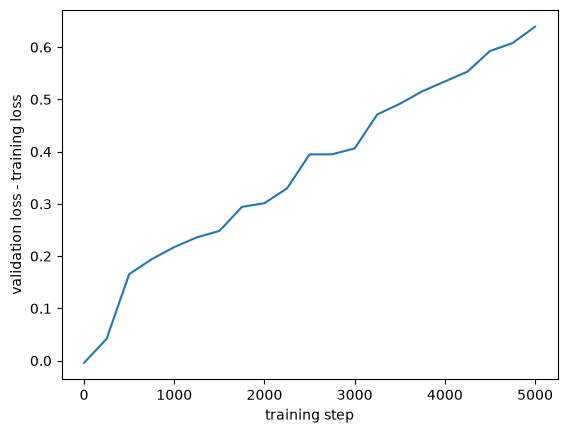

In [47]:
generalization_gaps: list[float] = [
    validation_loss - train_loss
    for train_loss, validation_loss in zip(
        train_losses,
        validation_losses,
    )
]

plt.figure()

plt.plot(
    logged_steps,
    generalization_gaps,
)

plt.xlabel("training step")

plt.ylabel("validation loss - training loss")

plt.show()

## Takeaways

Pretraining does not require explicit labels such as classes or human
preferences.

The supervision is already contained inside the sequence itself:

$$
x_1,x_2,\ldots,x_T
$$

creates the targets

$$
x_2,x_3,\ldots,x_{T+1}.
$$

The optimization objective is simply

$$
\mathcal{L}
=
-\sum_t
\log
p_\theta(
x_{t+1}
\mid
x_{\le t}
).
$$

Despite this simple objective, the model learns statistical structure at
multiple levels:

<pre>
characters
    ↓
spelling patterns
    ↓
word-like units
    ↓
syntax
    ↓
style
    ↓
partial semantics
</pre>

The experiment also demonstrates that lower training loss is not
automatically equivalent to a better language model.

Validation data is required to detect overfitting and select a
checkpoint that generalizes better.

Finally, generation is a separate stage from training.

The trained model defines a next-token distribution, while decoding
determines how that distribution is converted into an actual sequence.